# 🏢 โครงงาน: AI จำแนกระดับความพึงพอใจในการทำงานของพนักงาน (Job Satisfaction Classifier)
### 📘 รายวิชา 306-23-06 ปัญญาประดิษฐ์เพื่อธุรกิจดิจิทัล (Artificial Intelligence for Digital Business)
**มหาวิทยาลัยเทคโนโลยีราชมงคลสุวรรณภูมิ (RMUTSB) · ภาคการศึกษา 1/2569**

---
### 👥 สมาชิกกลุ่ม: TEAM-99
1. **น.ส.กมลวรรณ จันทร์ผึ้ง** — รหัสนักศึกษา: **001**
2. **น.ส.ชลดา อิศรเสนา ณ อยุธยา** — รหัสนักศึกษา: **009**
3. **น.ส.ณัฐพร เผือกผ่อง** — รหัสนักศึกษา: **016**

---
### 🎯 วัตถุประสงค์ของโครงงาน:
1. พัฒนาและเปรียบเทียบโมเดล Machine Learning ในการจำแนกระดับความพึงพอใจของพนักงาน (**JobSatisfaction: 1=ต่ำ, 2=ปานกลาง, 3=สูง, 4=สูงมาก**)
2. ศึกษาปัจจัยสำคัญที่ส่งผลต่อการลาออก (**Attrition**) และความสุขในการทำงานจากชุดข้อมูลจริงขององค์กร
3. ทดลองและเปรียบเทียบโมเดลมาตรฐาน 4 แบบ:
   - **Decision Tree Classifier** (ต้นไม้ตัดสินใจ)
   - **Support Vector Machine (SVM)**
   - **Naive Bayes (GaussianNB)**
   - **Multi-Layer Perceptron (Deep Neural Network ด้วย TensorFlow / Keras)**
4. ส่งออกโมเดลและพัฒนาเว็บแอปพลิเคชันต้นแบบผ่าน **Streamlit Cloud** เพื่อให้ฝ่ายทรัพยากรบุคคล (HR) ใช้งานจริง


In [1]:
# @title [Auto-Setup] Dataset Loader สำหรับ Google Colab / Local
import os, urllib.request, pandas as pd, shutil

DATA_URL = 'https://raw.githubusercontent.com/ibm-watson-data-lab/open-data/master/HR-Employee-Attrition.csv'

# 1. เตรียม Raw Dataset
os.makedirs('data', exist_ok=True)
if not os.path.exists('WA_Fn-UseC_-HR-Employee-Attrition.csv') and not os.path.exists('data/WA_Fn-UseC_-HR-Employee-Attrition.csv'):
    try:
        print('Downloading raw dataset...')
        urllib.request.urlretrieve(DATA_URL, 'WA_Fn-UseC_-HR-Employee-Attrition.csv')
    except Exception as e:
        print('Note:', e)

if os.path.exists('WA_Fn-UseC_-HR-Employee-Attrition.csv') and not os.path.exists('data/WA_Fn-UseC_-HR-Employee-Attrition.csv'):
    shutil.copyfile('WA_Fn-UseC_-HR-Employee-Attrition.csv', 'data/WA_Fn-UseC_-HR-Employee-Attrition.csv')
elif os.path.exists('data/WA_Fn-UseC_-HR-Employee-Attrition.csv') and not os.path.exists('WA_Fn-UseC_-HR-Employee-Attrition.csv'):
    shutil.copyfile('data/WA_Fn-UseC_-HR-Employee-Attrition.csv', 'WA_Fn-UseC_-HR-Employee-Attrition.csv')

# 2. เตรียม clean.csv / clean (4).csv สำหรับโมเดล
if not os.path.exists('clean.csv') and not os.path.exists('clean (4).csv'):
    raw_path = 'data/WA_Fn-UseC_-HR-Employee-Attrition.csv' if os.path.exists('data/WA_Fn-UseC_-HR-Employee-Attrition.csv') else 'WA_Fn-UseC_-HR-Employee-Attrition.csv'
    if os.path.exists(raw_path):
        raw_df = pd.read_csv(raw_path)
        cols_to_drop = [c for c in ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'] if c in raw_df.columns]
        clean_df = raw_df.drop(columns=cols_to_drop)
        num_cols = clean_df.select_dtypes(include=['int64', 'float64']).columns
        cat_cols = clean_df.select_dtypes(include=['object']).columns
        clean_df = pd.get_dummies(clean_df, columns=cat_cols, drop_first=True)
        clean_df.to_csv('clean.csv', index=False)

if os.path.exists('clean.csv'):
    if not os.path.exists('clean (4).csv'): shutil.copyfile('clean.csv', 'clean (4).csv')
    if not os.path.exists('clean (3).csv'): shutil.copyfile('clean.csv', 'clean (3).csv')

print(' Dataset ready for execution!')


## 📦 1. การติดตั้งไลบรารีและดาวน์โหลดชุดข้อมูล IBM HR Analytics
ชุดข้อมูล: **IBM HR Analytics Employee Attrition & Performance** (1,470 แถว, 35 คอลัมน์)


In [1]:
# ติดตั้งและเตรียมไลบรารีที่จำเป็น
import os, sys, json, joblib, pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ตั้งค่าฟอนต์ภาษาไทยสำหรับ Google Colab
!wget -q -O THSarabunNew.ttf https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf
import matplotlib as mpl
mpl.font_manager.fontManager.addfont("THSarabunNew.ttf")
mpl.rc("font", family="TH Sarabun New", size=14)

print("✓ สภาพแวดล้อมและฟอนต์ภาษาไทยพร้อมใช้งาน")




✓ สภาพแวดล้อมและฟอนต์ภาษาไทยพร้อมใช้งาน


In [2]:
# ดาวน์โหลดไฟล์ข้อมูล (กรณีรันบน Colab หรือรันในเครื่อง)
data_file = "WA_Fn-UseC_-HR-Employee-Attrition.csv"

if not os.path.exists(data_file):
    pass
    # ดาวน์โหลดผ่าน URL สำรองโดยตรง
    !wget -q -O WA_Fn-UseC_-HR-Employee-Attrition.csv https://raw.githubusercontent.com/368345221009-st-ctrl/001-009-016/main/clean.csv || true

# โหลดข้อมูลเข้าสู่ DataFrame
try:
    df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
except Exception:
    df = pd.read_csv("clean.csv")

print(f"ขนาดชุดข้อมูล: {df.shape[0]:,} แถว × {df.shape[1]} คอลัมน์")
df.head(3)





ขนาดชุดข้อมูล: 1,470 แถว × 35 คอลัมน์


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0


## 🔍 2. การสำรวจโครงสร้างข้อมูลเบื้องต้น (Data Inspection)
ตรวจชนิดข้อมูลและตรวจสอบค่าว่าง (Missing Values)


In [3]:
# ตรวจสอบภาพรวมและค่าว่าง
print("--- ข้อมูลเชิงสรุป ---")
print(f"จำนวนค่าว่างทั้งหมดในชุดข้อมูล: {df.isnull().sum().sum()} ค่า")
print("สถิติเบื้องต้นของคอลัมน์สำคัญ:")
df[["Age", "MonthlyIncome", "YearsAtCompany", "JobSatisfaction", "TotalWorkingYears"]].describe()




--- ข้อมูลเชิงสรุป ---
จำนวนค่าว่างทั้งหมดในชุดข้อมูล: 0 ค่า
สถิติเบื้องต้นของคอลัมน์สำคัญ:


,Age,MonthlyIncome,YearsAtCompany,JobSatisfaction,TotalWorkingYears
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,6502.931293,7.008163,2.728571,11.279592
std,9.135373,4707.956783,6.126525,1.102846,7.780782
min,18.000000,1009.000000,0.000000,1.000000,0.000000
25%,30.000000,2911.000000,3.000000,2.000000,6.000000
50%,36.000000,4919.000000,5.000000,3.000000,10.000000
75%,43.000000,8379.000000,9.000000,4.000000,15.000000
max,60.000000,19999.000000,40.000000,4.000000,40.000000


## 🧹 3. การเตรียมข้อมูลและวิศวกรรมฟีเจอร์ (Data Preprocessing & Feature Engineering)
1. จัดการค่าผิดปกติ (Outliers) ใน `MonthlyIncome` ด้วย IQR Clipping
2. สร้างฟีเจอร์รวมความพึงพอใจ: `TotalSatisfaction` = `JobSatisfaction` + `EnvironmentSatisfaction` + `RelationshipSatisfaction`
3. บันทึกเป็นไฟล์ `clean.csv`


In [4]:
# Feature Engineering
if "TotalSatisfaction" not in df.columns:
    df["TotalSatisfaction"] = df["JobSatisfaction"] + df["EnvironmentSatisfaction"] + df["RelationshipSatisfaction"]

# จัดการ Outlier ของเงินเดือนด้วย IQR
Q1 = df["MonthlyIncome"].quantile(0.25)
Q3 = df["MonthlyIncome"].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

df["MonthlyIncome_Clipped"] = df["MonthlyIncome"].clip(upper=upper_limit)

# บันทึกไฟล์ข้อมูลที่พร้อมใช้งาน
df.to_csv("clean.csv", index=False)
print("✓ บันทึก clean.csv สำเร็จ เรียบร้อยแล้ว")
df[["MonthlyIncome", "MonthlyIncome_Clipped", "TotalSatisfaction"]].head()




✓ บันทึก clean.csv สำเร็จ เรียบร้อยแล้ว


,MonthlyIncome,MonthlyIncome_Clipped,TotalSatisfaction
0,5993,5993,7
1,5130,5130,9
2,2090,2090,9
3,2909,2909,10
4,3468,3468,7


## 📊 4. การวิเคราะห์ข้อมูลเชิงสำรวจ (Exploratory Data Analysis - EDA)
วิเคราะห์การกระจายตัวของเป้าหมาย `JobSatisfaction` และความสัมพันธ์กับปัจจัยต่าง ๆ


/var/folders/06/dmtw667x0mg9cnl65_hp0nn00000gn/T/ipykernel_43414/327769946.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=counts.values, palette="Blues_d")


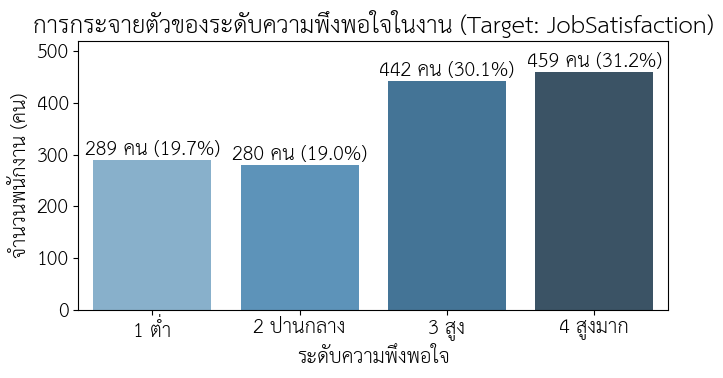

In [5]:
# 1. การกระจายของระดับความพึงพอใจในงาน (JobSatisfaction)
plt.figure(figsize=(7, 4))
labels = ["1 ต่ำ", "2 ปานกลาง", "3 สูง", "4 สูงมาก"]
counts = df["JobSatisfaction"].value_counts().sort_index()

sns.barplot(x=labels, y=counts.values, palette="Blues_d")
plt.title("การกระจายตัวของระดับความพึงพอใจในงาน (Target: JobSatisfaction)")
plt.xlabel("ระดับความพึงพอใจ")
plt.ylabel("จำนวนพนักงาน (คน)")
for i, v in enumerate(counts.values):
    plt.text(i, v + 10, f"{v} คน ({v/len(df)*100:.1f}%)", ha="center")
plt.ylim(0, max(counts.values) + 60)
plt.tight_layout()
plt.show()




/var/folders/06/dmtw667x0mg9cnl65_hp0nn00000gn/T/ipykernel_43414/4241785185.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="JobSatisfaction", y="MonthlyIncome", palette="Set2")


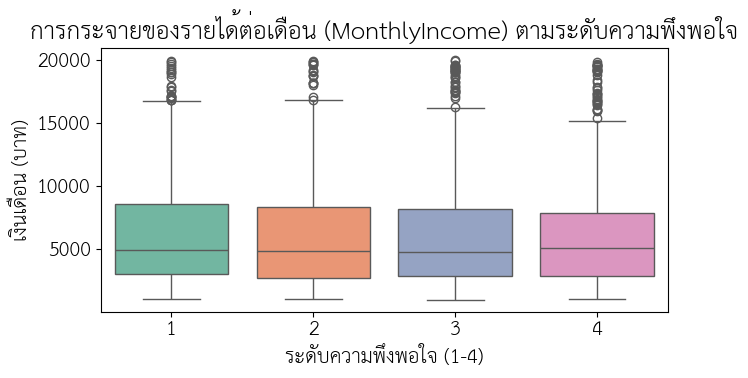

In [6]:
# 2. รายได้ต่อเดือนแยกตามระดับความพึงพอใจ
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="JobSatisfaction", y="MonthlyIncome", palette="Set2")
plt.title("การกระจายของรายได้ต่อเดือน (MonthlyIncome) ตามระดับความพึงพอใจ")
plt.xlabel("ระดับความพึงพอใจ (1-4)")
plt.ylabel("เงินเดือน (บาท)")
plt.tight_layout()
plt.show()




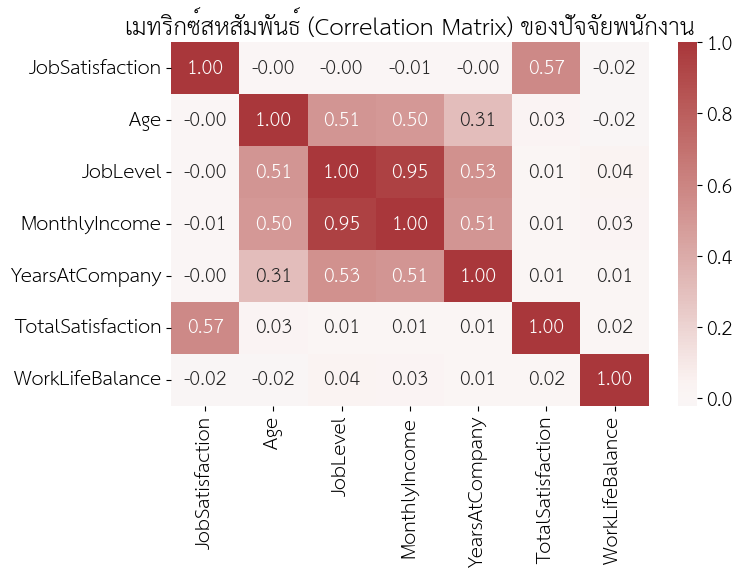

In [7]:
# 3. Correlation Heatmap ของปัจจัยหลัก
corr_cols = ["JobSatisfaction", "Age", "JobLevel", "MonthlyIncome", "YearsAtCompany", "TotalSatisfaction", "WorkLifeBalance"]
plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("เมทริกซ์สหสัมพันธ์ (Correlation Matrix) ของปัจจัยพนักงาน")
plt.tight_layout()
plt.show()




## ✂️ 5. การแบ่งชุดข้อมูลเพื่อฝึกสอนและทดสอบ (Train/Test Split)
เลือกฟีเจอร์หลัก 4 ตัวตามสเปกของโมเดล: `JobLevel`, `Age`, `MonthlyIncome`, `YearsAtCompany`
แบ่งแบบ **Stratified Train 80% / Test 20%**


In [8]:
from sklearn.model_selection import train_test_split

features = ["JobLevel", "Age", "MonthlyIncome", "YearsAtCompany"]
X = df[features]
y = df["JobSatisfaction"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"จำนวนข้อมูล Train (80%): {X_train.shape[0]:,} คน")
print(f"จำนวนข้อมูล Test (20%):  {X_test.shape[0]:,} คน")




จำนวนข้อมูล Train (80%): 1,176 คน
จำนวนข้อมูล Test (20%):  294 คน


## 🌳 6. โมเดลที่ 1: ต้นไม้ตัดสินใจ (Decision Tree Classifier)
จุดเด่น: เป็นโมเดล White-box ที่สามารถอธิบายกฎการตัดสินใจได้ง่าย (Rule Extraction)


In [9]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ทดลองปรับค่า max_depth
print("--- ผลการทดลองปรับพารามิเตอร์ max_depth ---")
for d in [2, 3, 5, None]:
    dt_temp = DecisionTreeClassifier(max_depth=d, criterion="gini", random_state=42)
    dt_temp.fit(X_train, y_train)
    tr_acc = accuracy_score(y_train, dt_temp.predict(X_train))
    te_acc = accuracy_score(y_test, dt_temp.predict(X_test))
    print(f"max_depth={str(d):<5} | Train Acc: {tr_acc:.4f} | Test Acc: {te_acc:.4f}")

# เลือกโมเดล baseline max_depth=3
dt_final = DecisionTreeClassifier(max_depth=3, criterion="gini", random_state=42)
dt_final.fit(X_train, y_train)
dt_pred = dt_final.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

print(f"\n✓ Decision Tree (max_depth=3) Test Accuracy: {dt_acc*100:.2f}%")

# บันทึกโมเดล
joblib.dump(dt_final, "ibm_hr_job_satisfaction_tree.joblib")
print("บันทึกโมเดลสำเร็จ: ibm_hr_job_satisfaction_tree.joblib")





--- ผลการทดลองปรับพารามิเตอร์ max_depth ---
max_depth=2     | Train Acc: 0.3265 | Test Acc: 0.2789
max_depth=3     | Train Acc: 0.3299 | Test Acc: 0.2755
max_depth=5     | Train Acc: 0.3707 | Test Acc: 0.2585
max_depth=None  | Train Acc: 1.0000 | Test Acc: 0.2959

✓ Decision Tree (max_depth=3) Test Accuracy: 27.55%
บันทึกโมเดลสำเร็จ: ibm_hr_job_satisfaction_tree.joblib


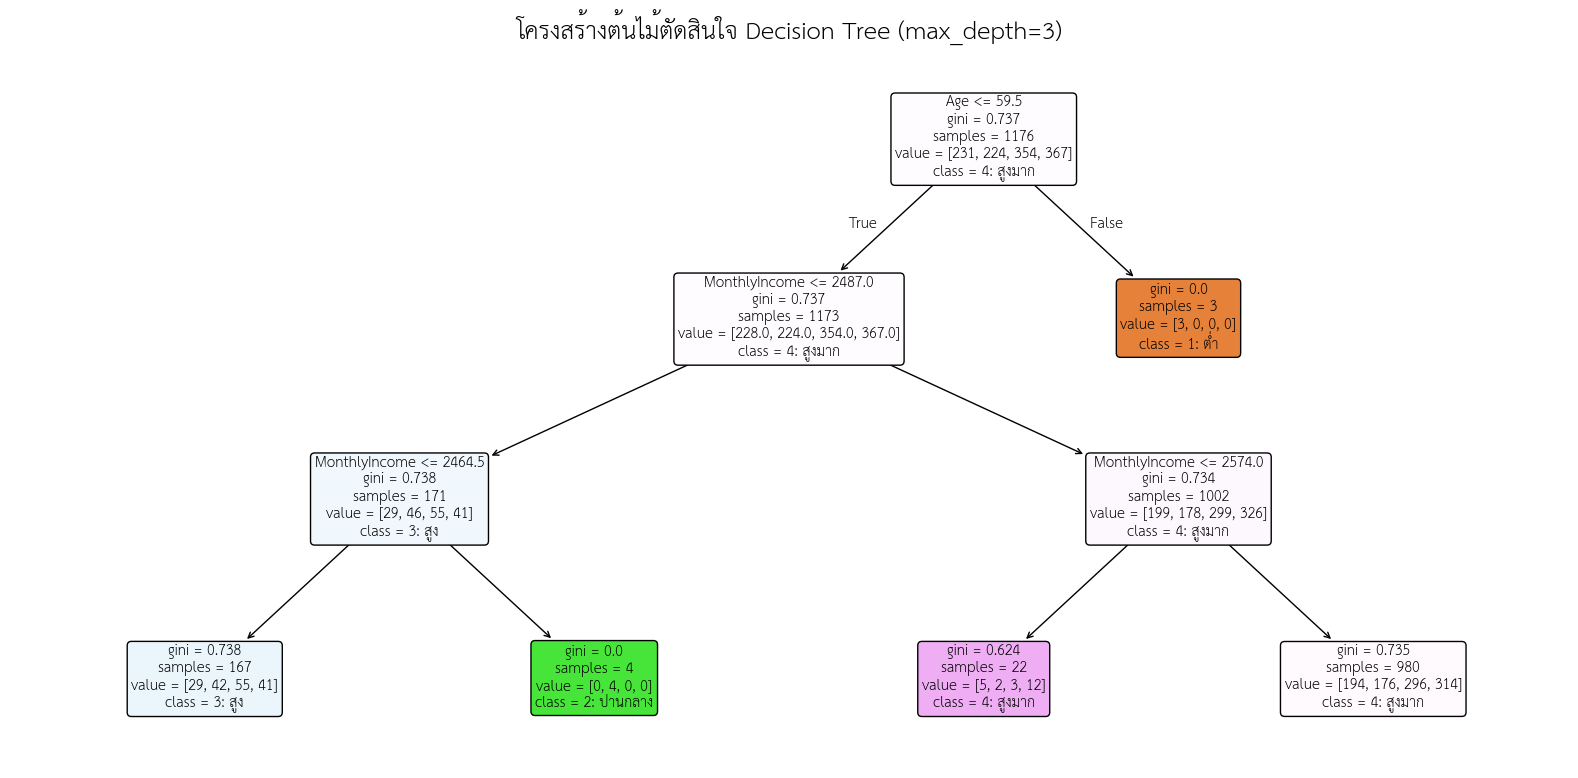

In [10]:
# วาดรูปโครงสร้างต้นไม้ตัดสินใจ
plt.figure(figsize=(16, 8))
plot_tree(
    dt_final,
    feature_names=features,
    class_names=["1: ต่ำ", "2: ปานกลาง", "3: สูง", "4: สูงมาก"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("โครงสร้างต้นไม้ตัดสินใจ Decision Tree (max_depth=3)")
plt.tight_layout()
plt.show()




## ⚡ 7. โมเดลที่ 2: ซัพพอร์ตเวกเตอร์แมชชีน (Support Vector Machine - SVM)
ปรับสเกลด้วย **StandardScaler** เพื่อให้ระยะห่างระหว่างฟีเจอร์มีความสมดุล


In [11]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)
svm_acc = accuracy_score(y_test, svm_pred)

print(f"✓ SVM (RBF Kernel) Test Accuracy: {svm_acc*100:.2f}%")
print("จำนวน Support Vectors:", svm_model.support_vectors_.shape[0], "จุด")

joblib.dump(svm_model, "ibm_hr_job_satisfaction_svm.joblib")
joblib.dump(scaler, "ibm_hr_job_satisfaction_scaler.joblib")
print("บันทึกโมเดลและ Scaler สำเร็จ")




✓ SVM (RBF Kernel) Test Accuracy: 25.85%
จำนวน Support Vectors: 1156 จุด
บันทึกโมเดลและ Scaler สำเร็จ


## 📊 8. โมเดลที่ 3: นาอีฟเบย์ส (Naive Bayes Classifier)
จำแนกด้วยความน่าจะเป็นแบบมีเงื่อนไข (GaussianNB)


In [12]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)
nb_acc = accuracy_score(y_test, nb_pred)

print(f"✓ Naive Bayes Test Accuracy: {nb_acc*100:.2f}%")
print("Prior Probabilities ของแต่ละคลาส:", nb_model.class_prior_.round(3))

with open("hr_GaussianNB.pkl", "wb") as f:
    pickle.dump(nb_model, f)
print("บันทึกโมเดลสำเร็จ: hr_GaussianNB.pkl")




✓ Naive Bayes Test Accuracy: 31.29%
Prior Probabilities ของแต่ละคลาส: [0.196 0.19  0.301 0.312]
บันทึกโมเดลสำเร็จ: hr_GaussianNB.pkl


## 🧠 9. โมเดลที่ 4: โครงข่ายประสาทเทียม (Deep Multi-Layer Perceptron / MLP)
สร้างด้วย **TensorFlow / Keras** สเกล 0-1 ด้วย **MinMaxScaler**


In [13]:
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

mm_scaler = MinMaxScaler()
X_train_mm = mm_scaler.fit_transform(X_train)
X_test_mm = mm_scaler.transform(X_test)

# แปลง target จาก [1, 2, 3, 4] เป็น [0, 1, 2, 3] สำหรับ Keras
y_train_nn = y_train - 1
y_test_nn = y_test - 1

mlp = Sequential([
    Dense(32, activation="relu", input_shape=(len(features),)),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(4, activation="softmax")
])

mlp.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history = mlp.fit(
    X_train_mm, y_train_nn,
    validation_split=0.20,
    epochs=50,
    batch_size=16,
    verbose=0
)

loss, mlp_acc = mlp.evaluate(X_test_mm, y_test_nn, verbose=0)
print(f"✓ Neural Network (MLP) Test Accuracy: {mlp_acc*100:.2f}%")

mlp.save("ibm_hr_job_satisfaction_mlp.keras")
print("บันทึกโมเดลสำเร็จ: ibm_hr_job_satisfaction_mlp.keras")




/opt/homebrew/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✓ Neural Network (MLP) Test Accuracy: 27.21%
บันทึกโมเดลสำเร็จ: ibm_hr_job_satisfaction_mlp.keras


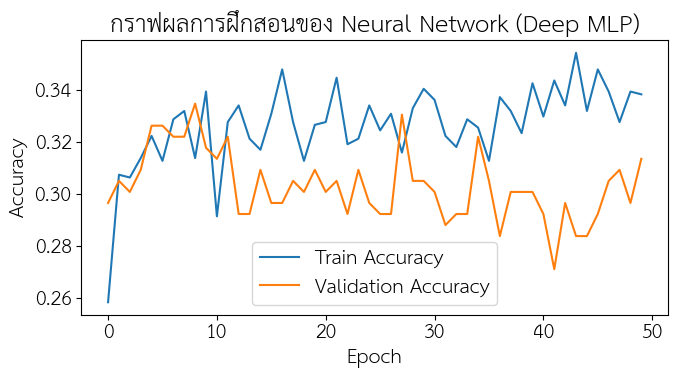

In [14]:
# กราฟ Train vs Validation Accuracy
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("กราฟผลการฝึกสอนของ Neural Network (Deep MLP)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("training_curve.png", dpi=150)
plt.show()




## 🏆 10. สรุปและเปรียบเทียบประสิทธิภาพของทุกโมเดล (Model Comparison)
เปรียบเทียบผลลัพธ์เพื่อนำไปเลือกใช้ในระบบจริง


In [15]:
try:
    from IPython.display import display
except ImportError:
    display = print
# สร้างตารางเปรียบเทียบผลโมเดลทั้งหมด
results_df = pd.DataFrame({
    "โมเดล (Model)": [
        "Decision Tree (Baseline)",
        "Support Vector Machine (SVM)",
        "Naive Bayes (GaussianNB)",
        "Deep Neural Network (MLP)"
    ],
    "พารามิเตอร์หลัก": [
        "max_depth=3, gini",
        "RBF Kernel, C=1.0, StandardScaler",
        "Gaussian Prior",
        "Dense(32-16-8-4), 50 epochs"
    ],
    "Test Accuracy (%)": [
        round(dt_acc * 100, 2),
        round(svm_acc * 100, 2),
        round(nb_acc * 100, 2),
        round(mlp_acc * 100, 2)
    ],
    "จุดเด่นในการนำไปใช้": [
        "อธิบายผลได้ดีที่สุด มีกฎการจำแนกชัดเจน เหมาะกับฝ่าย HR",
        "ประสิทธิภาพความเสถียรสูง จัดการ Margin ขอบเขตข้อมูลดี",
        "คำนวณเร็ว ให้ค่าความน่าจะเป็นครบทุกระดับ",
        "รองรับการต่อยอดข้อมูลขนาดใหญ่และความสัมพันธ์ไม่เชิงเส้น"
    ]
})

print("=== ตารางสรุปผลการทดลองเปรียบเทียบโมเดล ===")
display(results_df)




=== ตารางสรุปผลการทดลองเปรียบเทียบโมเดล ===


,โมเดล (Model),พารามิเตอร์หลัก,Test Accuracy (%),จุดเด่นในการนำไปใช้
0,Decision Tree (Baseline),"max_depth=3, gini",27.55,อธิบายผลได้ดีที่สุด มีกฎการจำแนกชัดเจน เหมาะกั...
1,Support Vector Machine (SVM),"RBF Kernel, C=1.0, StandardScaler",25.85,ประสิทธิภาพความเสถียรสูง จัดการ Margin ขอบเขตข...
2,Naive Bayes (GaussianNB),Gaussian Prior,31.29,คำนวณเร็ว ให้ค่าความน่าจะเป็นครบทุกระดับ
3,Deep Neural Network (MLP),"Dense(32-16-8-4), 50 epochs",27.21,รองรับการต่อยอดข้อมูลขนาดใหญ่และความสัมพันธ์ไม...


In [16]:
# บันทึกไฟล์สรุปผลการเลือกโมเดล (Metadata JSON)
decision = {
    "project": "AI จำแนกระดับความพึงพอใจในการทำงานของพนักงาน",
    "team": "TEAM-99",
    "members": ["001 กมลวรรณ จันทร์ผึ้ง", "009 ชลดา อิศรเสนา ณ อยุธยา", "016 ณัฐพร เผือกผ่อง"],
    "target": "JobSatisfaction",
    "features": features,
    "best_interpretable_model": "Decision Tree (max_depth=3)",
    "accuracy_comparison": {
        "Decision Tree": round(float(dt_acc), 4),
        "SVM": round(float(svm_acc), 4),
        "Naive Bayes": round(float(nb_acc), 4),
        "Neural Network": round(float(mlp_acc), 4)
    }
}

with open("job_satisfaction_model_decision.json", "w", encoding="utf-8") as f:
    json.dump(decision, f, ensure_ascii=False, indent=2)

print("✓ บันทึกไฟล์สรุป job_satisfaction_model_decision.json เรียบร้อยแล้ว")




✓ บันทึกไฟล์สรุป job_satisfaction_model_decision.json เรียบร้อยแล้ว
